#Analytic Task 2: Shooting Accuracy

#Analytic Question:
Is there a significant difference in shooting accuracy between forwards and midfielders during the FIFA World Cup 2026?

This analytic task investigates whether the average shooting accuracy of forwards differs significantly from that of midfielders during the FIFA World Cup 2026. The two groups being compared are forwards (FW) and midfielders (MF).

Shooting accuracy is calculated as the percentage of a player's total attempts at goal that were on target:

Shooting Accuracy (%)=
Attempts at Goal ÷
Attempts on Target ×100

Player-level data for this analysis will be obtained from the FIFA World Cup 2026 Player Statistics – Attacking dataset.

#Data Wrangling

Player-level data for this analysis were obtained from the FIFA World Cup 2026 Player Statistics – Attacking dataset. The variables relevant to this analysis are Player, Country, Position, Attempts on Target, and Attempts at Goal.

The dataset will be cleaned by separating player information into individual variables for Player, Country, and Position. Only players classified as midfielders (MF) or forwards (FW) will be retained, as these are the two groups being compared.

The dataset will also be checked for missing values and duplicate records. Players with zero attempts at goal will be excluded because shooting accuracy cannot be meaningfully calculated for players who did not attempt a shot.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving FIFA_World_Cup_2026_Q2_Data_Wrangling.xlsx to FIFA_World_Cup_2026_Q2_Data_Wrangling.xlsx


In [2]:
import pandas as pd

df2 = pd.read_excel(
    "FIFA_World_Cup_2026_Q2_Data_Wrangling.xlsx",
    sheet_name="Raw_FIFA_Attacking"
)

df2.head()

,Rank,Player,Assists,Attempts\nOn Target,Attempts\nAt Goal,Attempts At Goal\nConv. Rate (%),Attempts Inside\nthe Penalty Area,Attempts Outside\nthe Penalty Area,Headed Attempts\nat Goal,xG,xG\nEfficiency,Player\nInvolvements
0,1,Michael Olise\nFRA\nFW,7,5,20,0,10,10,0,2.34,0x,25
1,2,Martin Odegaard\nNOR\nMF,4,3,9,0,5,4,0,0.72,0x,12
2,2,Kylian Mbappe\nFRA\nFW,4,23,41,24,27,14,0,6.54,1.53x,5
3,2,Brahim Diaz\nMAR\nFW,4,1,6,0,4,2,0,0.31,0x,1
4,2,Bruno Guimaraes\nBRA\nMF,4,2,8,0,5,3,1,1.02,0x,8


In [3]:
# Check the size of the dataset
print("Dataset shape:", df2.shape)

# Check column names
print("\nColumn names:")
print(df2.columns.tolist())

# Check data types and missing values
print("\nDataset information:")
df2.info()

Dataset shape: (165, 12)

Column names:
['Rank', 'Player', 'Assists', 'Attempts\nOn Target', 'Attempts\nAt Goal', 'Attempts At Goal\nConv. Rate (%)', 'Attempts Inside\nthe Penalty Area', 'Attempts Outside\nthe Penalty Area', 'Headed Attempts\nat Goal', 'xG', 'xG\nEfficiency', 'Player\nInvolvements']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Rank                               165 non-null    int64  
 1   Player                             165 non-null    object 
 2   Assists                            165 non-null    int64  
 3   Attempts
On Target                 165 non-null    int64  
 4   Attempts
At Goal                   165 non-null    int64  
 5   Attempts At Goal
Conv. Rate (%)    165 non-null    int64  
 6   Attempts Inside
the Penalty Area   165 non-null    int6

In [4]:
# Replace line breaks in column names with spaces
df2.columns = df2.columns.str.replace("\n", " ", regex=False)

# Display the cleaned column names
print(df2.columns.tolist())

['Rank', 'Player', 'Assists', 'Attempts On Target', 'Attempts At Goal', 'Attempts At Goal Conv. Rate (%)', 'Attempts Inside the Penalty Area', 'Attempts Outside the Penalty Area', 'Headed Attempts at Goal', 'xG', 'xG Efficiency', 'Player Involvements']


In [5]:
# Extract country and position from the Player column
df2["Country"] = df2["Player"].str.extract(r'\n([A-Z]{3})')
df2["Position"] = df2["Player"].str.extract(r'\n[A-Z]{3}\n(GK|DF|MF|FW)')

# Keep only the player's name
df2["Player"] = df2["Player"].str.split("\n").str[0]

# Display the result
df2[["Player", "Country", "Position"]].head(10)

,Player,Country,Position
0,Michael Olise,FRA,FW
1,Martin Odegaard,NOR,MF
2,Kylian Mbappe,FRA,FW
3,Brahim Diaz,MAR,FW
4,Bruno Guimaraes,BRA,MF
5,Lionel Messi,ARG,FW
6,Roberto Alvarado,MEX,FW
7,Anthony Gordon,ENG,FW
8,Florian Wirtz,GER,MF
9,Andreas Schjelderup,NOR,MF


In [6]:
# Keep only the variables needed for Question 2
q2_df = df2[
    [
        "Player",
        "Country",
        "Position",
        "Attempts On Target",
        "Attempts At Goal"
    ]
].copy()

# Keep only midfielders and forwards
q2_df = q2_df[q2_df["Position"].isin(["MF", "FW"])]

# Reset the index
q2_df = q2_df.reset_index(drop=True)

# Display the cleaned dataset
q2_df.head(10)

,Player,Country,Position,Attempts On Target,Attempts At Goal
0,Michael Olise,FRA,FW,5,20
1,Martin Odegaard,NOR,MF,3,9
2,Kylian Mbappe,FRA,FW,23,41
3,Brahim Diaz,MAR,FW,1,6
4,Bruno Guimaraes,BRA,MF,2,8
5,Lionel Messi,ARG,FW,19,35
6,Roberto Alvarado,MEX,FW,0,5
7,Anthony Gordon,ENG,FW,4,6
8,Florian Wirtz,GER,MF,1,10
9,Andreas Schjelderup,NOR,MF,2,3


In [7]:
# Check how many midfielders and forwards remain
print(q2_df["Position"].value_counts())

print("\nTotal players:", len(q2_df))

Position
FW    65
MF    61
Name: count, dtype: int64

Total players: 126


In [8]:
# Remove players who had zero attempts at goal
q2_df = q2_df[q2_df["Attempts At Goal"] > 0].copy()

# Calculate shooting accuracy
q2_df["Shooting Accuracy (%)"] = (
    q2_df["Attempts On Target"] / q2_df["Attempts At Goal"]
) * 100

# Reset the index
q2_df = q2_df.reset_index(drop=True)

# Display the result
q2_df.head(10)

,Player,Country,Position,Attempts On Target,Attempts At Goal,Shooting Accuracy (%)
0,Michael Olise,FRA,FW,5,20,25.000000
1,Martin Odegaard,NOR,MF,3,9,33.333333
2,Kylian Mbappe,FRA,FW,23,41,56.097561
3,Brahim Diaz,MAR,FW,1,6,16.666667
4,Bruno Guimaraes,BRA,MF,2,8,25.000000
5,Lionel Messi,ARG,FW,19,35,54.285714
6,Roberto Alvarado,MEX,FW,0,5,0.000000
7,Anthony Gordon,ENG,FW,4,6,66.666667
8,Florian Wirtz,GER,MF,1,10,10.000000
9,Andreas Schjelderup,NOR,MF,2,3,66.666667


In [9]:
print("Players remaining:", len(q2_df))

print("\nPlayers by position:")
print(q2_df["Position"].value_counts())

Players remaining: 118

Players by position:
Position
FW    61
MF    57
Name: count, dtype: int64


In [10]:
# Check for missing values
print("Missing values:")
print(q2_df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", q2_df.duplicated().sum())

# Check for duplicate player names
print("Duplicate player names:", q2_df["Player"].duplicated().sum())

Missing values:
Player                   0
Country                  0
Position                 0
Attempts On Target       0
Attempts At Goal         0
Shooting Accuracy (%)    0
dtype: int64

Duplicate rows: 0
Duplicate player names: 0


Data Wrangling Summary:
The FIFA World Cup 2026 player attacking dataset was cleaned for the shooting accuracy analysis. Column names were cleaned by removing line breaks, and the Player field was separated into Player, Country, and Position variables. Only midfielders (MF) and forwards (FW) were retained because these are the two groups relevant to the analytic question. Players with zero attempts at goal were excluded because shooting accuracy could not be calculated for these players. Shooting Accuracy (%) was calculated as Attempts On Target ÷ Attempts At Goal × 100. The final dataset contained 118 eligible players, consisting of 61 forwards and 57 midfielders. The dataset was checked for missing values and duplicate records, and none were identified.

#Data Preparation and Sampling

The population for this analysis consists of 118 eligible midfielders and forwards from the cleaned FIFA World Cup 2026 attacking dataset. This population includes 61 forwards (FW) and 57 midfielders (MF). Players with zero attempts at goal were excluded during data wrangling because shooting accuracy could not be calculated for these players.

Stratified random sampling was used by dividing the population according to playing position. A random sample of 40 forwards and 40 midfielders was selected, resulting in a total sample size of 80 players. Equal sample sizes were selected to provide balanced representation of the two groups for statistical comparison.

In [11]:
# Separate players by position
midfielders_q2 = q2_df[q2_df["Position"] == "MF"]
forwards_q2 = q2_df[q2_df["Position"] == "FW"]

# Randomly sample 40 players from each group
mf_sample_q2 = midfielders_q2.sample(n=40, random_state=42)
fw_sample_q2 = forwards_q2.sample(n=40, random_state=42)

# Combine the samples
sample_q2 = pd.concat([mf_sample_q2, fw_sample_q2])

# Reset the index
sample_q2 = sample_q2.reset_index(drop=True)

# Display first 10 rows
sample_q2.head(10)

,Player,Country,Position,Attempts On Target,Attempts At Goal,Shooting Accuracy (%)
0,Martin Odegaard,NOR,MF,3,9,33.333333
1,Nicolas Raskin,BEL,MF,1,2,50.000000
2,Alex Baena,ESP,MF,5,12,41.666667
3,Mostafa Zico,EGY,MF,3,8,37.500000
4,Jude Bellingham,ENG,MF,13,19,68.421053
5,Lucas Paqueta,BRA,MF,1,5,20.000000
6,Orkun Kokcu,TUR,MF,0,3,0.000000
7,Akmal Mozgovoy,UZB,MF,0,1,0.000000
8,Nadiem Amiri,GER,MF,1,2,50.000000
9,Hannibal Mejbri,TUN,MF,1,3,33.333333


In [12]:
# Verify the sample
print("Total sample size:", len(sample_q2))

print("\nSample by position:")
print(sample_q2["Position"].value_counts())

Total sample size: 80

Sample by position:
Position
MF    40
FW    40
Name: count, dtype: int64


# Descriptive Statistics

Descriptive statistics are used to summarise and compare the shooting accuracy of the sampled midfielders and forwards. The mean, median, standard deviation, minimum, maximum, and sample size are calculated for each playing position.

In [13]:
# Calculate descriptive statistics for shooting accuracy by position
descriptive_stats_q2 = sample_q2.groupby("Position")["Shooting Accuracy (%)"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

# Round results to 2 decimal places
descriptive_stats_q2 = descriptive_stats_q2.round(2)

descriptive_stats_q2

,count,mean,median,std,min,max
Position,,,,,,
FW,40,39.94,44.44,28.18,0.0,100.0
MF,40,31.60,33.33,24.00,0.0,100.0


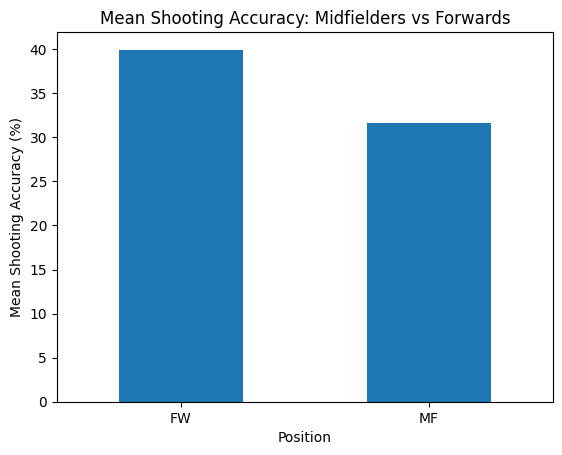

In [14]:
import matplotlib.pyplot as plt

mean_shooting = sample_q2.groupby("Position")["Shooting Accuracy (%)"].mean()

mean_shooting.plot(kind="bar")

plt.title("Mean Shooting Accuracy: Midfielders vs Forwards")
plt.xlabel("Position")
plt.ylabel("Mean Shooting Accuracy (%)")
plt.xticks(rotation=0)
plt.show()

Interpretation:
The descriptive statistics show that the sampled forwards had a higher mean shooting accuracy (39.94%) than the sampled midfielders (31.60%). The median shooting accuracy was also higher for forwards (44.44%) than midfielders (33.33%). The standard deviation was higher among forwards (28.18) than midfielders (24.00), indicating greater variability in shooting accuracy among the sampled forwards. Overall, the descriptive statistics suggest that forwards had higher shooting accuracy in the sample. However, inferential statistical analysis is required to determine whether this difference is statistically significant.

# Inferential Statistics

A 95% confidence interval is calculated for the mean shooting accuracy of midfielders and forwards. The confidence intervals provide a range of plausible values for the population mean shooting accuracy of each playing position based on the sample data.

In [15]:
import scipy.stats as stats

# Separate shooting accuracy for each group
mf_shooting = sample_q2[
    sample_q2["Position"] == "MF"
]["Shooting Accuracy (%)"]

fw_shooting = sample_q2[
    sample_q2["Position"] == "FW"
]["Shooting Accuracy (%)"]

# Function to calculate 95% confidence interval
def confidence_interval(data):
    n = len(data)
    mean = data.mean()
    std_error = stats.sem(data)

    lower, upper = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=mean,
        scale=std_error
    )

    return mean, lower, upper

# Calculate confidence intervals
mf_mean, mf_lower, mf_upper = confidence_interval(mf_shooting)
fw_mean, fw_lower, fw_upper = confidence_interval(fw_shooting)

print("Midfielders:")
print(f"Mean = {mf_mean:.2f}%")
print(f"95% CI = ({mf_lower:.2f}%, {mf_upper:.2f}%)")

print("\nForwards:")
print(f"Mean = {fw_mean:.2f}%")
print(f"95% CI = ({fw_lower:.2f}%, {fw_upper:.2f}%)")

Midfielders:
Mean = 31.60%
95% CI = (23.92%, 39.27%)

Forwards:
Mean = 39.94%
95% CI = (30.92%, 48.95%)


# Inferential Statistics — Two-Sample t-Test

A two-sample t-test is conducted to determine whether there is a statistically significant difference in mean shooting accuracy between forwards and midfielders.

Null hypothesis (H₀): There is no significant difference in mean shooting accuracy between forwards and midfielders.

Alternative hypothesis (H₁): There is a significant difference in mean shooting accuracy between forwards and midfielders.

The significance level is set at α = 0.05.

In [16]:
t_stat_q2, p_value_q2 = stats.ttest_ind(
    fw_shooting,
    mf_shooting,
    equal_var=False
)

print(f"T-statistic = {t_stat_q2:.4f}")
print(f"P-value = {p_value_q2:.4f}")

# Decision at alpha = 0.05
alpha = 0.05

if p_value_q2 < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean shooting accuracy.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean shooting accuracy.")

T-statistic = 1.4246
P-value = 0.1584
Fail to reject the null hypothesis.
There is no statistically significant difference in mean shooting accuracy.


Conclusion:
The analysis found that forwards had a higher average shooting accuracy than midfielders in the selected sample. However, the two-sample t-test showed that this difference was not statistically significant at the 5% significance level (p = 0.1584). Therefore, based on this sample, there is insufficient evidence to conclude that forwards and midfielders have different mean shooting accuracy in the FIFA World Cup 2026.